# Лабораторная работа F2 — Синтез фильтра по спецификации

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/f2.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/f2.html)**.

**Что разбираем.** В E3 мы брали готовый фильтр и смотрели, что он делает.
Здесь наоборот: записываем **требование** — что пропустить, что задавить и
насколько — и получаем самый дешёвый фильтр, который ему удовлетворяет.

Три вещи, которые проверим в коде:

1. порядок, посчитанный по формуле на бумаге, совпадает с тем, что выдаёт
   `scipy.signal.buttord` — до последней цифры;
2. ширина переходной полосы стоит дороже всех остальных требований вместе
   взятых: порядок растёт как $1/\lg r$;
3. КИХ при той же спецификации в десятки раз длиннее БИХ, и его длина
   напрямую превращается в задержку в миллисекундах.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Спецификация

Спецификация — это четыре числа и частота дискретизации:

| Обозначение | Что задаёт | Наш пример: убрать дрейф |
|---|---|---|
| $f_{гп}$ | граница полосы пропускания | 20 Гц — ниже мышцы почти нет |
| $f_{гз}$ | граница полосы задерживания | 8 Гц — здесь уже чистый дрейф |
| $\delta_{гп}$ | допустимая неравномерность в полосе пропускания | 1 дБ |
| $\delta_{гз}$ | требуемое затухание в полосе задерживания | 50 дБ |
| $F_д$ | частота дискретизации | 1000 Гц |

Взаимное расположение границ само задаёт тип: $f_{гп} > f_{гз}$ — это ФВЧ.

In [2]:
FS = 1000.0
F_STOP = 8.0        # f_гз
F_PASS = 20.0       # f_гп
D_PASS = 1.0        # δ_гп, дБ
D_STOP = 50.0       # δ_гз, дБ


def warp(f):
    """Предыскажение билинейного преобразования: Ω = tg(π f / F_д)."""
    return np.tan(np.pi * f / FS)


eps2 = 10 ** (D_PASS / 10) - 1
g = (10 ** (D_STOP / 10) - 1) / eps2
r = warp(F_PASS) / warp(F_STOP)          # избирательность ФВЧ

print("ε² = %.4f" % eps2)
print("g  = %.4g" % g)
print("r  = %.4f" % r)

ε² = 0.2589
g  = 3.862e+05
r  = 2.5028


## Ячейка 3 · Порядок по формуле против порядка из scipy

У Баттерворта квадрат АЧХ равен $|H(u)|^2 = 1/(1+\varepsilon^2 u^{2n})$, где
$u$ — во сколько раз частота «глубже» в полосе задерживания. Требование на
границе задерживания $u=r$ даёт $r^{2n} \ge g$, откуда

$$ n \ge \frac{\lg g}{2\,\lg r}. $$

У Чебышёва вместо степени $u^{n}$ стоит многочлен $T_n(u)$, растущий за
пределами $[-1,1]$ как $\cosh(n\,\mathrm{arch}\,u)$, поэтому
$n \ge \mathrm{arch}\sqrt{g}\,/\,\mathrm{arch}\,r$. У эллиптического фильтра
в той же роли выступает отношение полных эллиптических интегралов.

Три формулы — и ни одного вызова библиотеки. Проверим их против `scipy`.

In [3]:
from scipy.signal import buttord, cheb1ord, ellipord


def order_butter(r, g):
    return np.log10(g) / (2 * np.log10(r))


def order_cheby(r, g):
    return np.arccosh(np.sqrt(g)) / np.arccosh(r)


def ellip_k(k):
    """Полный эллиптический интеграл K(k) через арифметико-геометрическое среднее."""
    a, b = 1.0, np.sqrt(1 - k * k)
    for _ in range(40):
        a, b = (a + b) / 2, np.sqrt(a * b)
    return np.pi / (2 * a)


def order_ellip(r, g):
    k, k1 = 1 / r, 1 / np.sqrt(g)
    return (ellip_k(k) * ellip_k(np.sqrt(1 - k1 * k1))
            / (ellip_k(k1) * ellip_k(np.sqrt(1 - k * k))))


wp, ws = F_PASS / (FS / 2), F_STOP / (FS / 2)
print("%-14s %-10s %-8s %-8s %s" % ("прототип", "формула", "вверх", "scipy", "итог"))
for name, exact, from_scipy in (
        ("Баттерворта", order_butter(r, g), buttord(wp, ws, D_PASS, D_STOP)[0]),
        ("Чебышёва I", order_cheby(r, g), cheb1ord(wp, ws, D_PASS, D_STOP)[0]),
        ("эллиптический", order_ellip(r, g), ellipord(wp, ws, D_PASS, D_STOP)[0])):
    ok = "совпало" if int(np.ceil(exact)) == from_scipy else "РАСХОЖДЕНИЕ"
    print("%-14s %-10.4f %-8d %-8d %s"
          % (name, exact, int(np.ceil(exact)), from_scipy, ok))

прототип       формула    вверх    scipy    итог
Баттерворта    7.0112     8        8        совпало
Чебышёва I     4.5441     5        5        совпало
эллиптический  3.4580     4        4        совпало


Совпало всё. Это стоит осознать: `scipy` не делает ничего волшебного — он
считает ту же формулу. Понимая её, ты можешь оценить порядок в уме и сразу
сказать, реализуема ли задуманная спецификация, не открывая ноутбук.

## Ячейка 4 · Самое дорогое требование

В формуле $\lg r$ стоит в знаменателе. Значит при сужении переходной полосы
$r \to 1$, $\lg r \to 0$, и порядок улетает вверх без всякой границы.
Посмотрим на это как на график.

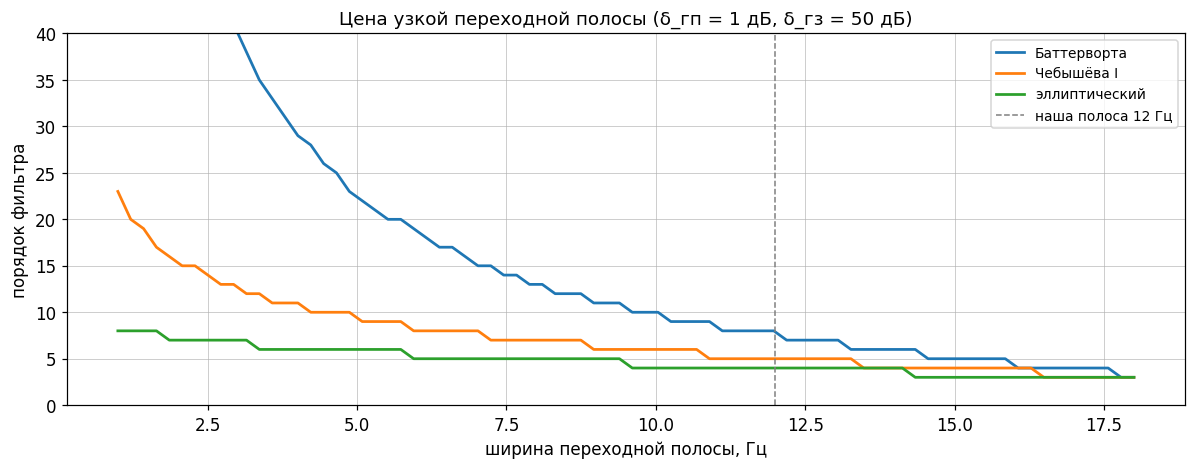

переходная полоса 12.0 Гц → порядок Баттерворта  8
переходная полоса  6.0 Гц → порядок Баттерворта 18
переходная полоса  3.0 Гц → порядок Баттерворта 40
переходная полоса  1.5 Гц → порядок Баттерворта 83


In [4]:
widths = np.linspace(1.0, 18.0, 80)
fig, ax = plt.subplots(figsize=(11, 4.4))
for label, fn in (("Баттерворта", order_butter), ("Чебышёва I", order_cheby),
                  ("эллиптический", order_ellip)):
    ax.plot(widths, [np.ceil(fn(warp(F_PASS) / warp(F_PASS - w), g)) for w in widths],
            lw=1.8, label=label)
ax.axvline(F_PASS - F_STOP, color="0.5", ls="--", lw=1,
           label="наша полоса %g Гц" % (F_PASS - F_STOP))
ax.set(xlabel="ширина переходной полосы, Гц", ylabel="порядок фильтра", ylim=(0, 40),
       title="Цена узкой переходной полосы (δ_гп = %g дБ, δ_гз = %g дБ)" % (D_PASS, D_STOP))
ax.legend(fontsize=9)
ax.grid(True, lw=.4)
fig.tight_layout()
plt.show()

for w in (12.0, 6.0, 3.0, 1.5):
    print("переходная полоса %4.1f Гц → порядок Баттерворта %2d"
          % (w, int(np.ceil(order_butter(warp(F_PASS) / warp(F_PASS - w), g)))))

Сузили полосу вдвое — порядок вырос чуть больше чем вдвое, и так каждый раз.
Сравни это с ценой других требований: подними $\delta_{гз}$ с 50 до 80 дБ, то
есть потребуй давить в тридцать раз сильнее по амплитуде, и порядок вырастет
с 8 всего до 11 — потому что $\delta$ входит под логарифм, а ширина полосы
стоит в знаменателе.

In [5]:
for stop_db in (30, 50, 80):
    g_alt = (10 ** (stop_db / 10) - 1) / eps2
    print("δ_гз = %2d дБ → порядок %d"
          % (stop_db, int(np.ceil(order_butter(r, g_alt)))))
for pass_db in (0.1, 1.0, 3.0):
    e_alt = 10 ** (pass_db / 10) - 1
    g_alt = (10 ** (D_STOP / 10) - 1) / e_alt
    print("δ_гп = %.1f дБ → порядок %d"
          % (pass_db, int(np.ceil(order_butter(r, g_alt)))))

δ_гз = 30 дБ → порядок 5
δ_гз = 50 дБ → порядок 8
δ_гз = 80 дБ → порядок 11
δ_гп = 0.1 дБ → порядок 9
δ_гп = 1.0 дБ → порядок 8
δ_гп = 3.0 дБ → порядок 7


## Ячейка 5 · БИХ и КИХ по одной спецификации

Теперь синтезируем сами коэффициенты. БИХ — через `iirdesign`, КИХ — методом
окна Кайзера: `kaiserord` по требуемому затуханию и ширине переходной полосы
сразу выдаёт нужную длину, `firwin` строит коэффициенты.

И главное — **проверим** результат на обеих границах полос. Формула даёт
оценку, а не гарантию: округление вверх и пересчёт частот могут сдвинуть АЧХ.

БИХ Баттерворта: порядок 8
    |H(f_гп)| = -1.00 дБ  (норма ≥ -1)
    |H(f_гз)| = -57.88 дБ  (норма ≤ -50)
КИХ Кайзера: 247 коэффициентов, β = 4.5335
    |H(f_гп)| = -0.02 дБ  (норма ≥ -1)
    |H(f_гз)| = -55.16 дБ  (норма ≤ -50)
    задержка = (N-1)/2 = 123 отсчётов = 123 мс
    КИХ длиннее БИХ в 31 раз


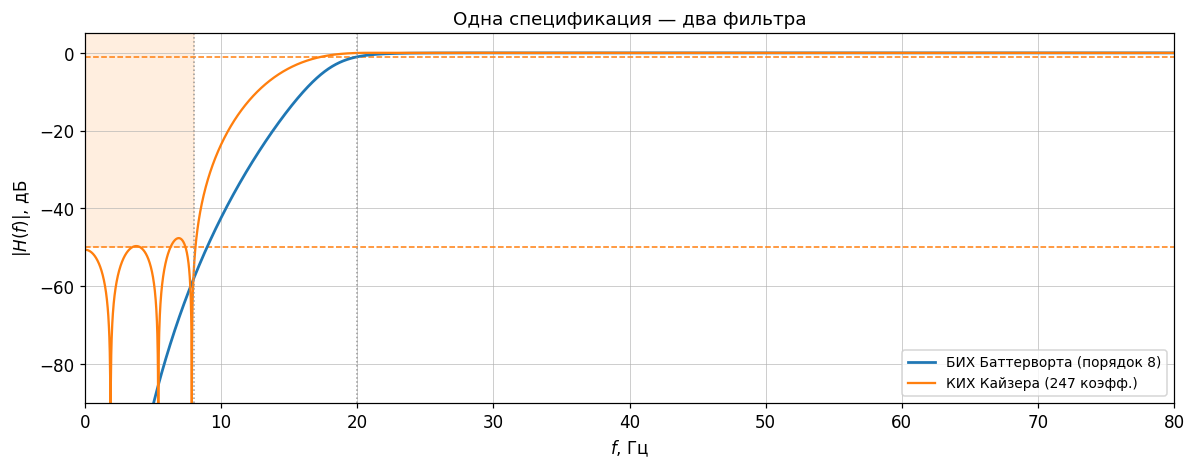

In [6]:
from scipy.signal import iirdesign, sosfreqz, kaiserord, firwin, freqz

sos = iirdesign(wp, ws, D_PASS, D_STOP, ftype="butter", output="sos")
iir_order = 2 * sos.shape[0]

taps, beta = kaiserord(D_STOP, abs(wp - ws))
if taps % 2 == 0:
    taps += 1                                  # ФВЧ требует нечётной длины
b = firwin(taps, (wp + ws) / 2, window=("kaiser", beta), pass_zero=False)
delay_ms = (taps - 1) / 2 / FS * 1000

w, h_iir = sosfreqz(sos, worN=2 ** 15)
f_axis = w * FS / (2 * np.pi)
db_iir = 20 * np.log10(np.abs(h_iir) + 1e-15)
_, h_fir = freqz(b, worN=2 ** 15)
db_fir = 20 * np.log10(np.abs(h_fir) + 1e-15)

print("БИХ Баттерворта: порядок %d" % iir_order)
print("    |H(f_гп)| = %+.2f дБ  (норма ≥ -%g)" % (np.interp(F_PASS, f_axis, db_iir), D_PASS))
print("    |H(f_гз)| = %+.2f дБ  (норма ≤ -%g)" % (np.interp(F_STOP, f_axis, db_iir), D_STOP))
print("КИХ Кайзера: %d коэффициентов, β = %.4f" % (taps, beta))
print("    |H(f_гп)| = %+.2f дБ  (норма ≥ -%g)" % (np.interp(F_PASS, f_axis, db_fir), D_PASS))
print("    |H(f_гз)| = %+.2f дБ  (норма ≤ -%g)" % (np.interp(F_STOP, f_axis, db_fir), D_STOP))
print("    задержка = (N-1)/2 = %.0f отсчётов = %.0f мс" % ((taps - 1) / 2, delay_ms))
print("    КИХ длиннее БИХ в %.0f раз" % (taps / iir_order))

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.axvspan(0, F_STOP, ymin=(90 - D_STOP) / 95, color="tab:orange", alpha=0.13)
ax.axhline(-D_PASS, color="tab:orange", ls="--", lw=1)
ax.axhline(-D_STOP, color="tab:orange", ls="--", lw=1)
ax.plot(f_axis, db_iir, lw=1.8, label="БИХ Баттерворта (порядок %d)" % iir_order)
ax.plot(f_axis, db_fir, lw=1.5, label="КИХ Кайзера (%d коэфф.)" % taps)
ax.axvline(F_STOP, color="0.6", ls=":", lw=1)
ax.axvline(F_PASS, color="0.6", ls=":", lw=1)
ax.set(xlim=(0, 80), ylim=(-90, 5), xlabel="$f$, Гц", ylabel="$|H(f)|$, дБ",
       title="Одна спецификация — два фильтра")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, lw=.4)
fig.tight_layout()
plt.show()

Спецификация здесь совершенно обычная для ЭМГ, а КИХ на ней уже не проходит
по задержке: больше 100 мс между движением мышцы и реакцией протеза человек
замечает как «вязкость». Это и есть ответ на вопрос, почему в реальном
протезе стоит БИХ, хотя у КИХ фаза строго линейная.

## Ячейка 6 · Проверка на сигнале

Синтетическая ЭМГ с огибающей сокращения плюс дрейф изолинии — медленное
блуждание нуля от движения электрода и пота. Дрейф здесь больше самой мышцы
по амплитуде, что для реальной записи совершенно обычно.

In [7]:
# ЯЧЕЙКА · Синтетическая ЭМГ из отдельных разрядов.
# Дальше все сигналы в этой работе строятся этими четырьмя функциями.
#
# Мышца состоит из двигательных единиц — мотонейрон плюс все волокна, которыми
# он управляет. Каждая единица разряжается 8–20 раз в секунду, и каждый разряд
# даёт на электроде короткий двухфазный всплеск: MUAP, потенциал действия
# двигательной единицы. Поверхностный электрод складывает разряды многих
# единиц — получается «интерференционная» ЭМГ, шумоподобная на вид.

import numpy as np


def muap(fs, ms=10.0):
    """Форма одного разряда: двухфазный всплеск длиной ms миллисекунд.

    Берём производную гауссианы — простейшая форма с двумя фазами и нулевым
    средним, то есть без постоянной составляющей, как у настоящего MUAP.
    """
    half = max(2, round(ms / 1000 * fs / 2))
    t = np.arange(2 * half + 1) - half
    sigma = (2 * half + 1) / 6
    shape = -(t / sigma ** 2) * np.exp(-t ** 2 / (2 * sigma ** 2))
    return shape / np.abs(shape).max()


def synth_emg(n, fs, units=10, seed=0):
    """Интерференционная ЭМГ: сумма разрядов нескольких двигательных единиц.

    У каждой единицы своя частота разрядов и своя амплитуда, а интервалы между
    разрядами слегка гуляют — поэтому сумма и выглядит шумоподобной.
    Результат нормирован на единичное СКО.
    """
    rng = np.random.default_rng(seed)
    shape = muap(fs)
    x = np.zeros(n)
    for _ in range(units):
        rate = rng.uniform(8, 20)                 # разрядов в секунду
        amplitude = rng.uniform(0.5, 1.5)
        position = rng.uniform(0, fs / rate)
        while position < n - len(shape):
            start = int(round(position))
            x[start:start + len(shape)] += amplitude * shape
            position += (fs / rate) * rng.uniform(0.75, 1.25)
    x /= np.sqrt(np.mean(x ** 2)) or 1.0
    return x + 0.05 * rng.standard_normal(n)      # шум усилителя


def mains_hum(n, fs):
    """Наводка от электросети: 50 Гц плюс гармоники 100 и 150 Гц."""
    t = np.arange(n) / fs
    return (np.sin(2 * np.pi * 50 * t)
            + 0.35 * np.sin(2 * np.pi * 100 * t)
            + 0.15 * np.sin(2 * np.pi * 150 * t))


def median_frequency(freqs, psd, band=(20.0, 450.0)):
    """MDF: частота, ниже которой лежит половина мощности сигнала в полосе.

    Считается по спектру мощности, поэтому качество оценки спектра прямо
    определяет, насколько устойчиво получается MDF.
    """
    inside = (freqs >= band[0]) & (freqs <= band[1])
    cumulative = np.cumsum(psd[inside])
    return float(freqs[inside][np.searchsorted(cumulative, cumulative[-1] / 2)])


print("Готово: muap, synth_emg, mains_hum, median_frequency")

Готово: muap, synth_emg, mains_hum, median_frequency


размах на участке покоя (первые 1,2 с): было 6.09 → стало 1.30


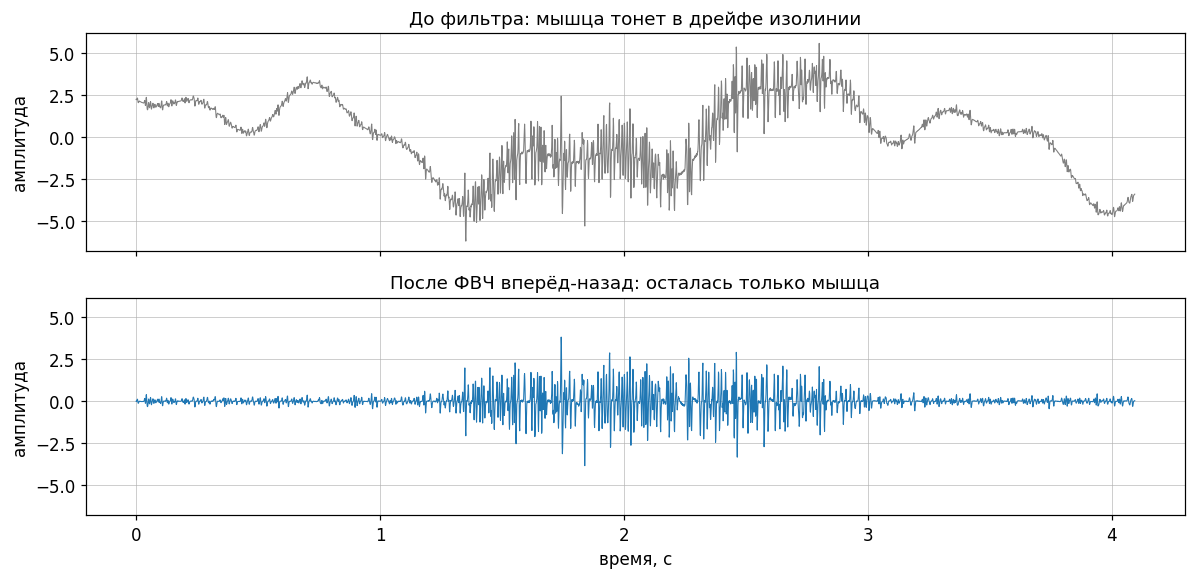

In [8]:
from scipy.signal import sosfiltfilt

N = 4096


def emg_burst(n, fs=FS, seed=20260826):
    """ЭМГ с огибающей: покой → сокращение → покой."""
    x = synth_emg(n, fs, seed=seed)
    p = np.arange(n) / n
    envelope = 0.12 + 0.88 / (1 + np.exp(-(p - 0.33) * 60)) \
                    * (1 - 1 / (1 + np.exp(-(p - 0.70) * 60)))
    return envelope * x


def baseline_drift(n, fs=FS):
    """Дрейф изолинии: медленное блуждание нуля."""
    t = np.arange(n) / fs
    return (2.4 * np.sin(2 * np.pi * 0.4 * t + 0.7)
            + 1.5 * np.sin(2 * np.pi * 1.1 * t + 2.1)
            + 0.8 * np.sin(2 * np.pi * 2.3 * t + 4.0))


raw = emg_burst(N) + baseline_drift(N)
clean = sosfiltfilt(sos, raw)

rest = slice(0, 1200)
print("размах на участке покоя (первые 1,2 с): было %.2f → стало %.2f"
      % (np.ptp(raw[rest]), np.ptp(clean[rest])))

t = np.arange(N) / FS
fig, axes = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True, sharey=True)
axes[0].plot(t, raw, lw=0.7, color="0.5")
axes[0].set(ylabel="амплитуда", title="До фильтра: мышца тонет в дрейфе изолинии")
axes[1].plot(t, clean, lw=0.7, color="tab:blue")
axes[1].set(xlabel="время, с", ylabel="амплитуда",
            title="После ФВЧ вперёд-назад: осталась только мышца")
for axis in axes:
    axis.grid(True, lw=.4)
fig.tight_layout()
plt.show()

Фильтр применён `sosfiltfilt` — вперёд и назад, как в E3, поэтому фазового
сдвига нет вовсе. Это законно для разбора записи, но невозможно в реальном
времени: чтобы отфильтровать назад, нужно знать будущее. В протезе остаётся
однократный проход — и вместе с ним фазовая задержка, которую мы только что
посчитали.

## Задания

1. Подставь спецификацию своего варианта и запиши $r$, $g$ и три порядка.
   Сверь их со `scipy` — расхождений быть не должно.
2. Найди спецификацию, при которой задержка КИХ впервые превышает 100 мс.
   Насколько при этом пришлось сузить переходную полосу?
3. По ячейке 4 определи, во сколько раз растёт порядок при сужении переходной
   полосы вдвое. Совпадает ли это с тем, что даёт формула $\lg g/(2\lg r)$?
4. Замени `ftype="butter"` на `"cheby1"` и `"ellip"` в ячейке 5 и посмотри,
   что происходит с АЧХ в полосе пропускания при меньшем порядке.
5. Подними $f_{гп}$ до 60 Гц и посмотри на сигнал в ячейке 6. Дрейф ушёл —
   но сколько мышцы ушло вместе с ним?